Processed data is stored in pkl file<br>
Load data and fit with PyMC<br>
Pt100 KOH CO oxidation<br>

Updates: 
1. ER_3 eliminated for bad fits. 
2. LH_3 eliminated for bad fits. 
3. LH_2 eliminated for bad fits. 
4. ER_2 looks good. 
5. ER_2_3: KO rhat
6. ER_LH_2: KO divergences
7. ER_LH_2_3: KO rhat (+ divergences rate)

# Initialization - Rate only

In [1]:
import numpy as np
import pymc as pm
import arviz as az
import pandas as pd
import xarray as xr
import pickle 
import nutpie
import matplotlib.pyplot as plt
import pytensor.tensor as pt
import itertools

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', None)

# Experimental conditions and constants 
C_KOH_list = np.array([0.1, 0.25, 0.5, 1]) # in M 
P_CO_list = 0.01*np.array([0.1, 1, 10, 100]) # in atm
conditions = list(itertools.product(C_KOH_list, P_CO_list))
R, T, F = 8.3145, 293.15, 96485
kb_eV, h, kb_J = 8.617e-5, 6.626e-34, 1.3806e-23  # eV/K, J.s, J/K 

# Load and parse data
with open('Pt100_KOH_replicates.pkl', 'rb') as f:
    experiments_interp = pickle.load(f)

E_list, C_list, P_list = [], [], []
log_rate_list, log_rate_SD_list = [], []
alpha_list, alpha_SD_list = [], []

for i, C_KOH in enumerate(C_KOH_list):
    for j, P_CO in enumerate(P_CO_list):
        cond = experiments_interp[(C_KOH, P_CO)]
        E = cond['E']
        E_list.append(E)
        C_list.append(np.full_like(E, C_KOH))
        P_list.append(np.full_like(E, P_CO))
        log_rate_list.append(cond['log_rate'])
        log_rate_SD_list.append(cond['log_rate_SD'])
        alpha_list.append(cond['alpha'])
        alpha_SD_list.append(cond['alpha_SD'])

E_in = np.concatenate(E_list)
C_KOH_in = np.concatenate(C_list)
P_CO_in = np.concatenate(P_list)
log_rate_obs = np.concatenate(log_rate_list)
log_rate_obs_SD = np.concatenate(log_rate_SD_list)
alpha_obs = np.concatenate(alpha_list)
alpha_obs_SD = np.concatenate(alpha_SD_list)

def add_post_sampling_observables(trace):
    """
    Calculates rate_linear and alpha after sampling to save PyMC compilation overhead.
    Injects them directly into the trace.posterior so plotting functions work unchanged.
    """
    # 1. Calculate rate_linear (fast NumPy exponentiation)
    trace.posterior['rate_linear'] = np.exp(trace.posterior['log_rate_model'])
    
    # 2. Calculate alpha
    log_rate_samples = trace.posterior['log_rate_model'].values # Shape: (chains, draws, total_E_points)
    alpha_samples = np.zeros_like(log_rate_samples)
    
    start = 0
    for E_arr in E_list:
        length = len(E_arr)
        end = start + length
        dE = E_arr[1] - E_arr[0]
        
        # np.gradient handles central and edge differences automatically
        gradient = np.gradient(log_rate_samples[:, :, start:end], dE, axis=2)
        alpha_samples[:, :, start:end] = (R * T / F) * gradient
        
        start = end
        
    # Inject alpha into the trace using the exact same dimension names as log_rate_model
    dims = trace.posterior['log_rate_model'].dims
    trace.posterior['alpha'] = (dims, alpha_samples)
    
    return trace

def calculate_flattened_r2(ppc, var_name):
    y_true = ppc.observed_data[var_name].values
    y_pred = ppc.posterior_predictive[var_name].values
    chains, draws, N = y_pred.shape
    y_pred_flat = y_pred.reshape(chains * draws, N)
    r2 = az.r2_score(y_true, y_pred_flat)
    return r2['r2']

In [2]:
def plot_posteriors(trace, model, target='word'): 
    
    all_vars = list(trace.posterior.data_vars)
    excluded_vars = ['alpha', 'rate_linear', 'log_rate', 'log_rate_model']
    var_names = [v for v in all_vars if not v.endswith("__")]
    kinetic_vars = [v for v in var_names if not v.startswith('theta') and v not in excluded_vars]

    summary = az.summary(trace, var_names=kinetic_vars)
    print(summary)
    
    num_vars = len(kinetic_vars)
    cols = min(4, max(1, num_vars)) 
    rows = int(np.ceil(num_vars / cols)) 

    if target == 'ppt':
        rc_update = {'font.size': 14, 'axes.linewidth': 1.5, 'lines.linewidth': 2}
        figsize_post = (3.0 * cols, 3.5 * rows) 
        figsize_pair = (8, 8)
        title_size = 20
        text_size_adj = 12 
    else:
        rc_update = {'font.size': 10, 'axes.linewidth': 1, 'lines.linewidth': 1.5}
        figsize_post = (2.5 * cols, 3.0 * rows) 
        figsize_pair = (8, 8)
        title_size = 14
        text_size_adj = 10

    # Use a context manager so we don't permanently alter or break notebook plotting behavior
    with plt.rc_context(rc_update):
        if kinetic_vars:
            axes = az.plot_posterior(trace, var_names=kinetic_vars, hdi_prob=0.95, 
                              round_to=3, figsize=figsize_post, grid=(rows, cols),
                              textsize=text_size_adj)
            
            axes_flat = np.array(axes).flatten() 
            for ax in axes_flat: 
                # ArviZ sometimes returns empty axes to fill out the grid; only format populated ones
                if ax is not None and hasattr(ax, 'texts'):
                    for text_obj in ax.texts: 
                        if 'mean' in text_obj.get_text():
                            text_obj.set_fontweight('bold')
                    ax.title.set_fontweight('bold')
                    
            plt.subplots_adjust(hspace=0.5, wspace=0.3, top=0.88) 
            plt.show()

        if len(kinetic_vars) > 1:
            az.plot_pair(trace, var_names=kinetic_vars, kind='kde', divergences=True, 
                         figsize=figsize_pair, textsize=10)
            plt.show()

    with model: ppc = pm.sample_posterior_predictive(trace, progressbar=False)

    for var_name in ppc.observed_data.data_vars:
        r2 = calculate_flattened_r2(ppc, var_name)
        print(f"{var_name}: {r2:.3f}")
      
    return ppc

def plot_model_fits(trace, ppc, target='word'):
    if target == 'ppt':
        plt.rcParams.update({'font.size': 14, 'axes.linewidth': 1.5, 'lines.linewidth': 2.5})
        figsize_4x4 = (12, 11)   # Reduced height to stop vertical stretching
        title_size, label_size = 18, 14
    else:
        plt.rcParams.update({'font.size': 10, 'axes.linewidth': 1, 'lines.linewidth': 2})
        figsize_4x4 = (7.5, 7)
        title_size, label_size = 12, 10

    colors = plt.cm.tab10.colors[:len(P_CO_list)]

    def get_model_data(var_name_fit, var_name_track):
        if var_name_fit in ppc.posterior_predictive.data_vars:
            return ppc.posterior_predictive[var_name_fit], False 
        else:
            return trace.posterior[var_name_track], True 

    def plot_grid(var_fit, var_track, nrows, ncols, figsize, ylabel, title_text):
        model_data_xr, is_det = get_model_data(var_fit, var_track)
        share_y = False if var_fit == 'rate_linear' else True
        
        fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, sharex=True, sharey=share_y)
        fig.suptitle(title_text, fontsize=title_size, fontweight='bold', y=0.97)

        start_idx = 0 # Changed: Track global flat index
        for i, C_KOH in enumerate(C_KOH_list):
            for j, P_CO in enumerate(P_CO_list):
                ax = axes[j, i]
                cond_key = (C_KOH, P_CO)

                E_exp = experiments_interp[cond_key]['E']
                length = len(E_exp) # Changed: get length of this specific E grid
                end_idx = start_idx + length # Changed: compute end boundary
                
                col_map = {'rate':'log_rate', 'rate_linear':'rate', 'alpha':'alpha'}
                exp_mean = experiments_interp[cond_key][col_map[var_fit]]
                exp_sd = experiments_interp[cond_key][col_map[var_fit]+'_SD']
                
                model_slice = model_data_xr[:, :, start_idx:end_idx] # Changed: slice 1D flattened dimension
                model_mean = model_slice.mean(dim=("chain", "draw"))
                hdi_95 = az.hdi(model_slice, hdi_prob=0.95)[model_slice.name]
                hdi_90 = az.hdi(model_slice, hdi_prob=0.90)[model_slice.name]

                if is_det:
                    ax.fill_between(E_exp, exp_mean - exp_sd, exp_mean + exp_sd, color='gray', alpha=0.3, linewidth=0, zorder=1)
                ax.plot(E_exp, exp_mean, color='black', lw=2.5, alpha=0.6, zorder=2)

                # Model HDI
                ax.fill_between(E_exp, hdi_95[:, 0].values, hdi_95[:, 1].values, color=colors[j], alpha=0.15, linewidth=0, zorder=3)
                ax.fill_between(E_exp, hdi_90[:, 0].values, hdi_90[:, 1].values, color=colors[j], alpha=0.30, linewidth=0, zorder=4)
                
                # Thicker Model Mean Line
                ax.plot(E_exp, model_mean, color=colors[j], lw=3.2, zorder=5)

                if j == 0: ax.set_title(f'{C_KOH} M KOH', fontsize=label_size, fontweight='bold')
                if i == 3: ax.text(1.05, 0.5, f'{P_CO} atm', transform=ax.transAxes, rotation=-90, va='center', fontsize=label_size, fontweight='bold')
                
                if j == (nrows-1): ax.set_xlabel(r"E (V$_{\mathbf{SHE}}$)", fontweight='bold')
                if i == 0: ax.set_ylabel(ylabel, fontweight='bold')
                
                start_idx = end_idx # Changed: Advance global flat index

        plt.tight_layout(); plt.subplots_adjust(right=0.92, top=0.91); plt.show()

    plot_grid('rate', 'log_rate', 4, 4, figsize_4x4, "log Rate", "Log Rate")
    plot_grid('rate_linear', 'rate_linear', 4, 4, figsize_4x4, "Rate", "Linear Rate")
    plot_grid('alpha', 'alpha', 4, 4, figsize_4x4, "alpha", "Transfer Coefficients")
    # Removed delta plots
    plt.rcParams.update(plt.rcParamsDefault)

def plot_coverages(trace, target='word'):
    if target == 'ppt':
        plt.rcParams.update({'font.size': 14, 'axes.linewidth': 1.5, 'lines.linewidth': 2.5})
        figsize = (12, 11) # Shorter height
        title_size, label_size = 20, 16
    else:
        plt.rcParams.update({'font.size': 10, 'axes.linewidth': 1, 'lines.linewidth': 2})
        figsize = (7.5, 7)
        title_size, label_size = 12, 10

    fig, axes = plt.subplots(nrows=4, ncols=4, figsize=figsize, sharex=True, sharey=True)
    fig.suptitle('Modeled Surface Coverages', fontsize=title_size, fontweight='bold', y=0.97)

    start_idx = 0 # Changed: Track global flat index
    for i, C_KOH in enumerate(C_KOH_list):
        for j, P_CO in enumerate(P_CO_list):
            ax = axes[j, i]
            E_exp = experiments_interp[(C_KOH, P_CO)]['E']
            length = len(E_exp) # Changed
            end_idx = start_idx + length # Changed

            for var, col, lab in zip(['theta_CO', 'theta_OH', 'theta_COOH'], 
                                     ['tab:red', 'tab:blue', 'tab:green'], 
                                     [r'$\theta_{CO}$', r'$\theta_{OH}$', r'$\theta_{COOH}$']):
                if var in trace.posterior:
                    data = trace.posterior[var][:, :, start_idx:end_idx] # Changed: Slice 1D flattened dimension
                    mu = data.mean(dim=("chain", "draw"))
                    hdi = az.hdi(data, hdi_prob=0.95)[var]
                    ax.fill_between(E_exp, hdi[:, 0], hdi[:, 1], color=col, alpha=0.15, linewidth=0)
                    ax.plot(E_exp, mu, color=col, label=lab, lw=2.5)

            ax.set_ylim(-0.05, 1.05)
            if j == 0: ax.set_title(f'{C_KOH} M KOH', fontsize=label_size, fontweight='bold')
            if i == 3: ax.text(1.05, 0.5, f'{P_CO} atm', transform=ax.transAxes, rotation=-90, va='center', fontsize=label_size, fontweight='bold')
            if j == 3: ax.set_xlabel(r"E (V$_{\mathbf{SHE}}$)", fontweight='bold')
            if i == 0: ax.set_ylabel("Coverage", fontweight='bold')        
            if i == 0 and j == 0: ax.legend(loc='upper right', frameon=False, fontsize=10)
            
            start_idx = end_idx # Changed: Advance global flat index

    plt.tight_layout(); plt.subplots_adjust(right=0.92, top=0.91); plt.show()
    plt.rcParams.update(plt.rcParamsDefault)

In [3]:
def fit_and_evaluate(model, draws=1000, tune=2000, chains=4, cores=4, init_mean=None, target_accept=0.99):
    compiled_model = nutpie.compile_pymc_model(model)
    trace = nutpie.sample(compiled_model, draws=draws, tune=tune, chains=chains, cores=cores, init_mean=init_mean, target_accept=target_accept)
    pm.compute_log_likelihood(trace, progressbar=False, model=model)
    loo = az.loo(trace, pointwise=True)
    print(loo)
    az.plot_khat(loo)
    plt.title("Pareto k diagnostic (Global Model)"); plt.show()
    trace = add_post_sampling_observables(trace)
    return trace, loo

def observables(log_rate_model): 
    # mu_alpha = calc_observables(log_rate_model)
    # pm.Deterministic('alpha', mu_alpha)
    # pm.Deterministic('rate_linear', pt.exp(log_rate_model))
    pm.Deterministic('log_rate_model', log_rate_model)
    log_rate = pm.StudentT('rate', nu=3, mu=log_rate_model, sigma=log_rate_obs_SD, observed=log_rate_obs)
    return log_rate

# LH 2

# ER 2

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.18,23
,3000,0,0.16,47
,3000,0,0.17,7
,3000,0,0.17,7


Computed from 4000 posterior samples and 468 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -828.92    49.34
p_loo       33.71        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      468  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



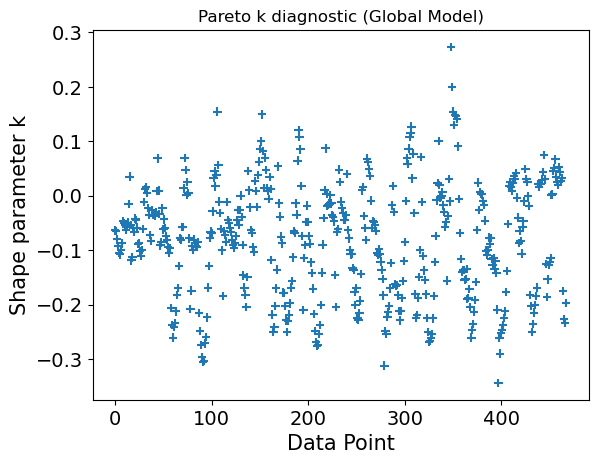

In [4]:
# Eley-Rideal Model - 2nd step is RDS  
with pm.Model() as ER_2:
    '''
    1. CO + * -> CO* 
    2. CO* + OH- -> COOH* + (e-) (RDS)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) 
    4. OH- + * -> OH* + (e-)
    '''
    # Priors
    deltaG1_0 = pm.Uniform('deltaG1_0', lower=-0.6, upper=0.0) 
    deltaG4_0 = pm.Uniform('deltaG4_0', lower=-0.2, upper=0.2) # at 0V_SHE
    beta_2 = pm.Uniform('beta_2', lower=0.1, upper=0.9)     
    Gact2_0 = pm.Uniform('Gact2_0', lower=0.5, upper=1.5) # at 0V_SHE

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    Gact2 = Gact2_0 - beta_2*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH = log_K4 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO + term_OH)
    log_theta = - pt.logsumexp(pt.stack([zeros, term_CO+zeros, term_OH+zeros]), axis=0)
    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))

    # Rate expression
    log_rate_model = log_k2 + log_theta_CO + np.log(C_KOH_in)
    log_rate = observables(log_rate_model) 

trace_ER_2, loo_ER_2 = fit_and_evaluate(ER_2)

            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0 -0.127  0.002  -0.132   -0.123        0.0      0.0    1040.0    1298.0   1.00
deltaG4_0 -0.015  0.006  -0.025   -0.004        0.0      0.0     961.0    1296.0   1.01
beta_2     0.281  0.006   0.269    0.293        0.0      0.0     915.0    1333.0   1.00
Gact2_0    1.251  0.001   1.250    1.252        0.0      0.0    1144.0    1818.0   1.00


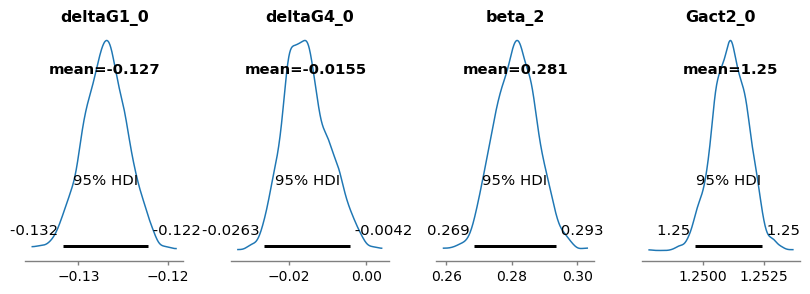

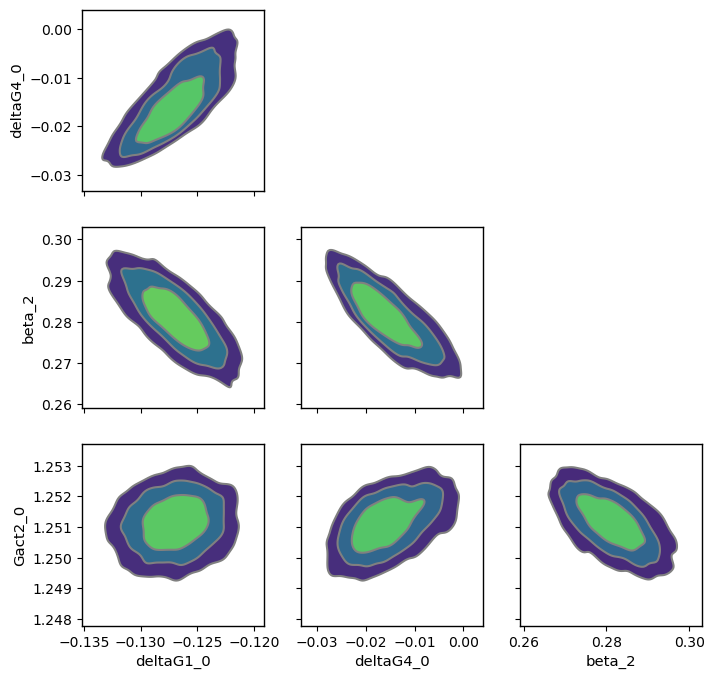

Sampling: [rate]


rate: 0.782


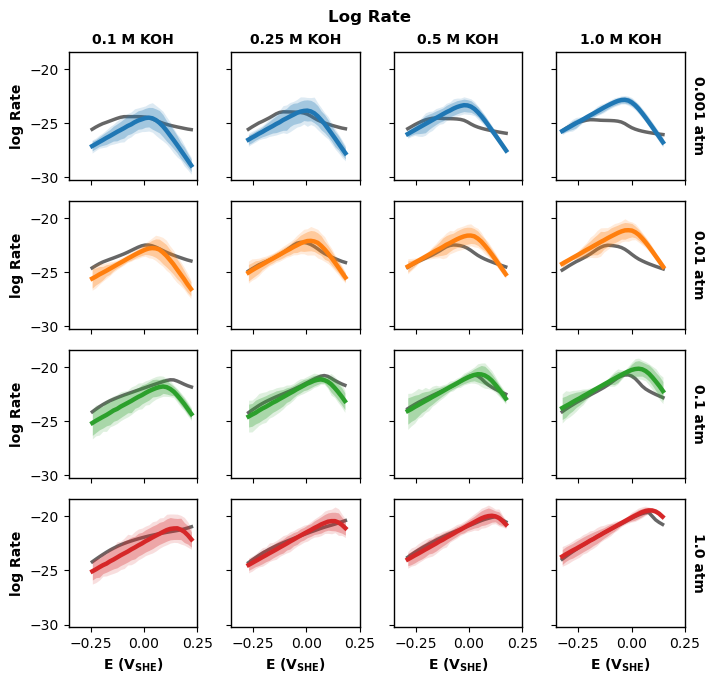

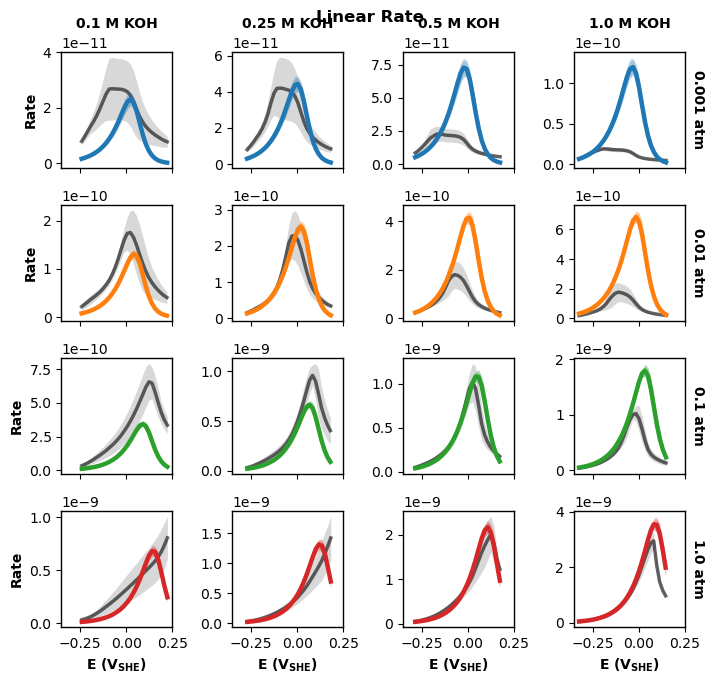

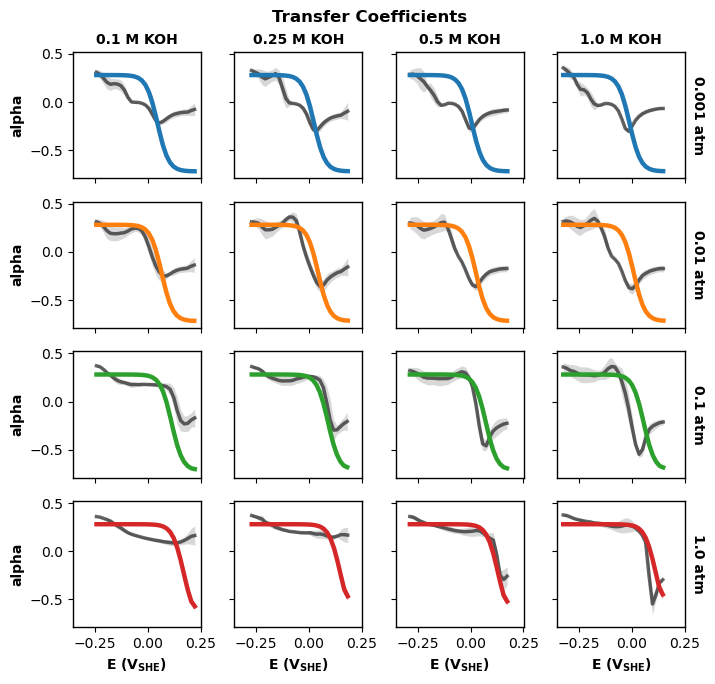

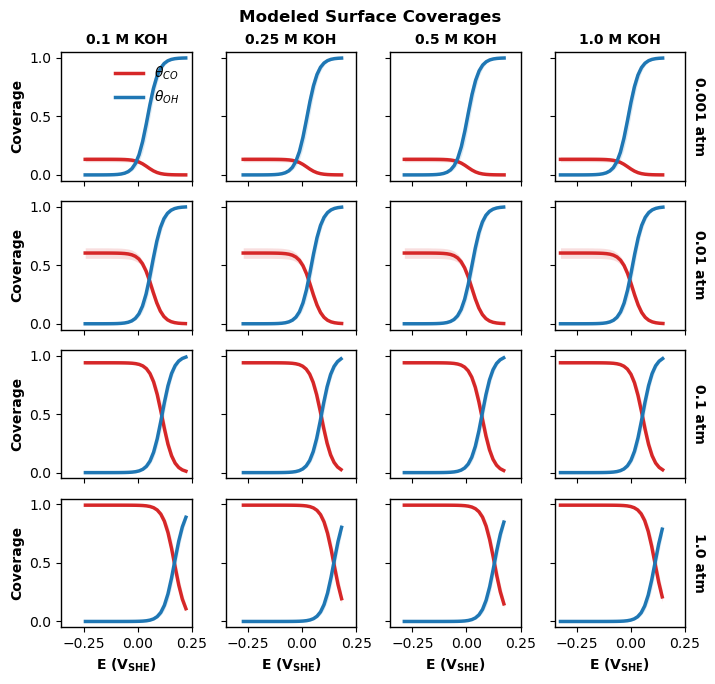

In [5]:
ppc_ER_2 = plot_posteriors(trace_ER_2, ER_2, format)
plot_model_fits(trace_ER_2, ppc_ER_2); plot_coverages(trace_ER_2)

# ER 3

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.14,31
,3000,0,0.14,31
,3000,0,0.16,23
,3000,0,0.14,31


Computed from 4000 posterior samples and 468 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -1389.44    65.95
p_loo       24.27        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      468  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



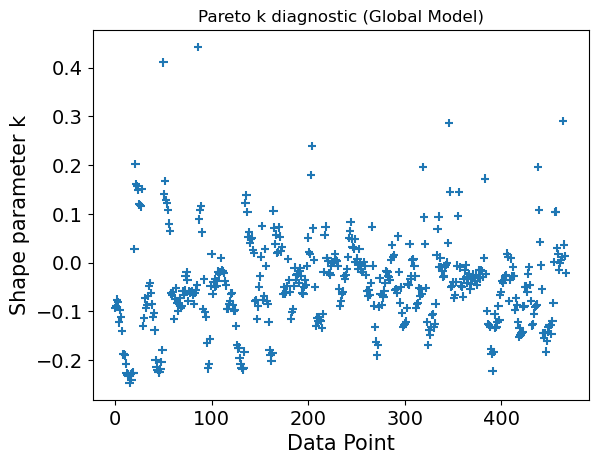

In [6]:
# Eley-Rideal Model - 3rd step is RDS  
with pm.Model() as ER_3:
    '''
    1. CO + * -> CO* 
    2. CO* + OH- -> COOH* + (e-) 
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (RDS)
    4. OH- + * -> OH* + (e-)
    '''
    # Priors
    deltaG1_0 = pm.Uniform('deltaG1_0', lower=-0.6, upper=0.0) 
    deltaG4_0 = pm.Uniform('deltaG4_0', lower=-0.2, upper=0.2) # at 0V_SHE
    deltaG2_0 = pm.Normal('deltaG2_0', mu=0, sigma=0.2) # at 0V_SHE
    beta_3 = pm.Uniform('beta_3', lower=0.1, upper=0.9)
    Gact3_0 = pm.Uniform('Gact3_0', lower=0.5, upper=1.5) # at 0V_SHE
    
    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG2 = deltaG2_0 - E_in
    deltaG4 = deltaG4_0 - E_in
    Gact3 = Gact3_0 - beta_3*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K2 = -deltaG2/(kb_eV*T)
    log_k3 = np.log(kb_J*T/h) - Gact3/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH = log_K4 + np.log(C_KOH_in)
    term_COOH = log_K2 + term_CO + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_COOH)
    log_theta = - pt.logsumexp(pt.stack([zeros, term_CO+zeros, term_OH+zeros, term_COOH]), axis=0) 
    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta
    log_theta_COOH = term_COOH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))
    theta_COOH = pm.Deterministic('theta_COOH', pt.exp(log_theta_COOH))

    # Rate expression
    log_rate_model = log_k3 + log_theta_COOH + np.log(C_KOH_in)
    log_rate = observables(log_rate_model)

trace_ER_3, loo_ER_3 = fit_and_evaluate(ER_3)

            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG2_0 -0.274  0.007  -0.287   -0.263        0.0      0.0     784.0     990.0    1.0
deltaG1_0 -0.031  0.006  -0.042   -0.019        0.0      0.0     897.0    1110.0    1.0
deltaG4_0 -0.200  0.000  -0.200   -0.199        0.0      0.0    3014.0    1543.0    1.0
beta_3     0.110  0.007   0.100    0.123        0.0      0.0    1116.0    1255.0    1.0
Gact3_0    1.258  0.001   1.257    1.260        0.0      0.0    3307.0    2522.0    1.0


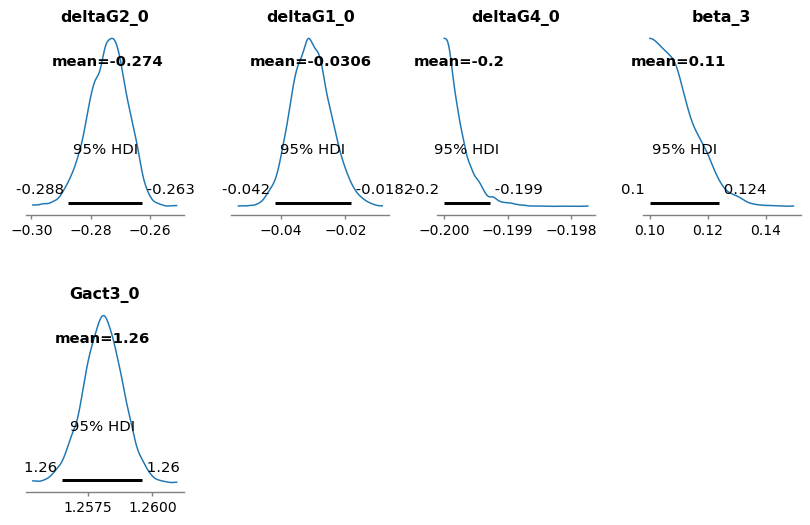

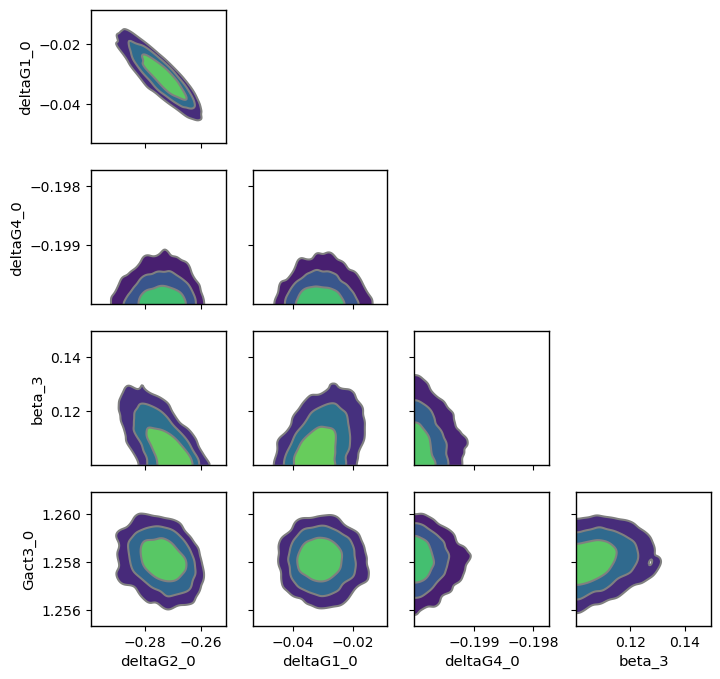

Sampling: [rate]


rate: 0.665


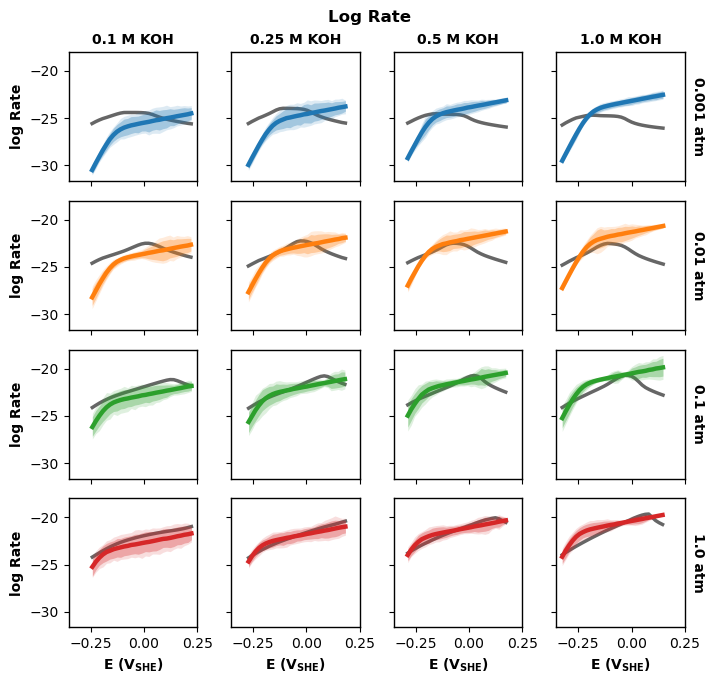

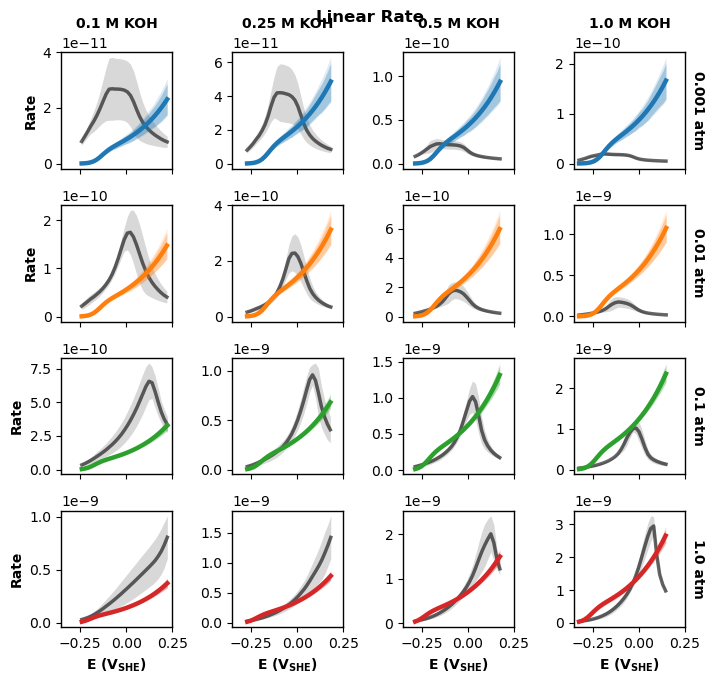

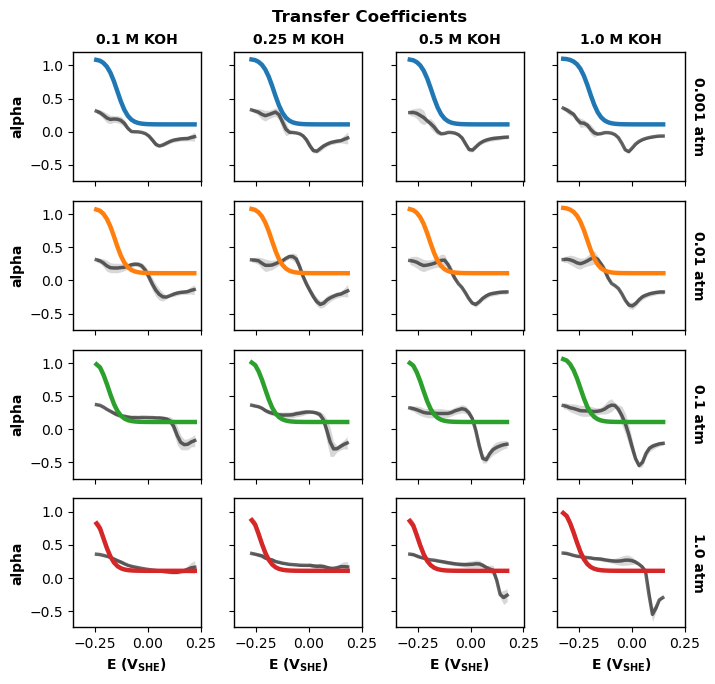

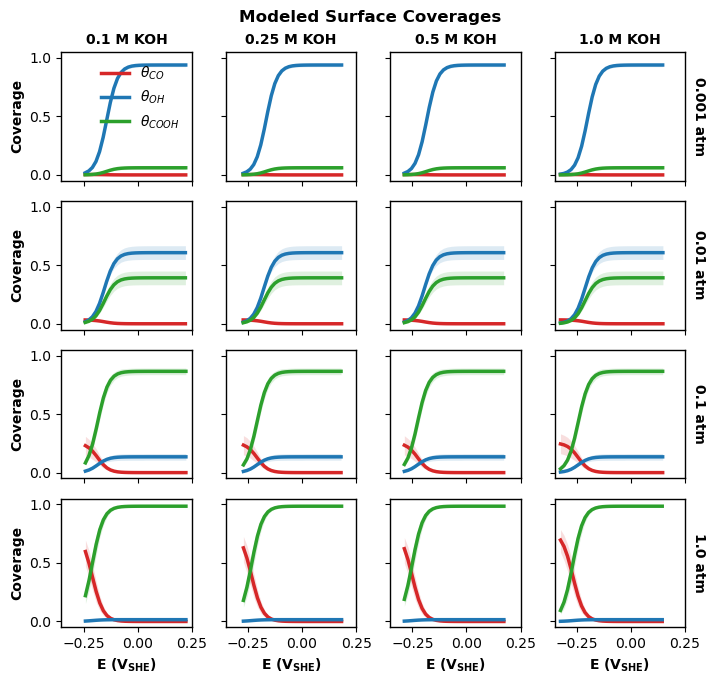

In [7]:
ppc_ER_3 = plot_posteriors(trace_ER_3, ER_3, format)
plot_model_fits(trace_ER_3, ppc_ER_3); plot_coverages(trace_ER_3)

# LH 3

# Full

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.12,63
,3000,0,0.13,31
,3000,1,0.12,31
,3000,307,0.11,1


Computed from 4000 posterior samples and 468 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -1618.97    79.86
p_loo       28.85        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      460   98.3%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    8    1.7%



c:\Users\awast\miniconda3\envs\jdftx_env\Lib\site-packages\arviz\stats\stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


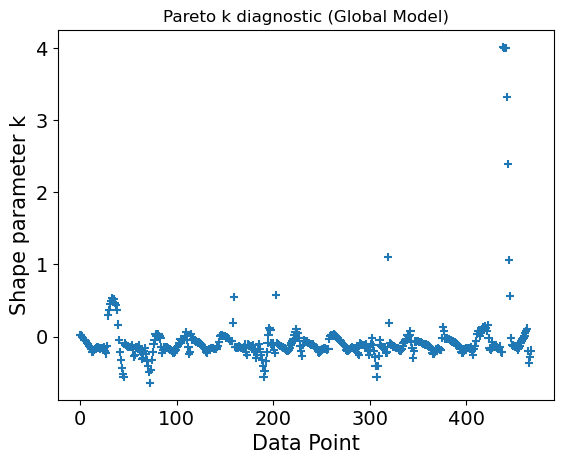

In [8]:
# Full model: All reactions considered - SSA - no QEA steps

# Collision theory 
m_CO = 28.01e-3 / 6.022e23 # Mass of CO molecule in kg
P_atm_to_Pa = 101325 # Conversion factor from atm to Pa
A_site = np.pi*(139e-12)**2 # Surface area of a single site
k1f = P_atm_to_Pa*A_site /np.sqrt(2*np.pi*m_CO*kb_J*T)
kT_eV = kb_eV * T
kT_J = kb_J * T

with pm.Model() as full:
    '''
    1. CO + * <-> CO* (Collision Theory) 
    2a. CO* + OH- <-> COOH* + (e-) (ER) 
    2b. CO* + OH* <-> COOH* + * (LH)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Irr) 
    4. OH- + * <-> OH* + (e-) 
    '''
    # Priors
    deltaG1_0    = pm.Uniform('deltaG1_0', lower=-0.4, upper=0.0)
    # deltaG1_0 = -0.5
    deltaG4_0    = pm.Uniform('deltaG4_0', lower=-0.1, upper=0.1) # at 0V_SHE
    # deltaG4_0 = 0.0 
    deltaG2_ER_0 = pm.Uniform('deltaG2_ER_0', lower=-0.5, upper=0.0) # at 0V_SHE
    Gact2_LH_0   = pm.Uniform('Gact2_LH_0', lower=1, upper=1.4) 
    Gact2_ER_0   = pm.Uniform('Gact2_ER_0', lower=1, upper=1.4) # at 0V_SHE
    Gact3_0      = pm.Uniform('Gact3_0', lower=1, upper=1.4) # at 0V_SHE
    Gact4_0      = pm.Uniform('Gact4_0', lower=0.8, upper=1.4) # at 0V_SHE
    beta_2       = pm.Uniform('beta_2', lower=0.2, upper=0.8)
    beta_3       = pm.Uniform('beta_3', lower=0.2, upper=0.8)
    beta_4       = pm.Uniform('beta_4', lower=0.2, upper=0.8)
    # beta_2 = 0.3
    # beta_3 = 0.4
    # beta_4 = 0.6

    # Thermodynamics 
    deltaG1    = deltaG1_0
    deltaG2_ER = deltaG2_ER_0 - E_in
    deltaG4    = deltaG4_0 - E_in
    deltaG2_LH = deltaG2_ER_0 - deltaG4_0
    K1    = pt.exp(-deltaG1 / kT_eV)
    K2_LH = pt.exp(-deltaG2_LH / kT_eV)
    K2_ER = pt.exp(-deltaG2_ER / kT_eV)
    K4    = pt.exp(-deltaG4 / kT_eV)
    Gact2_LH = Gact2_LH_0 
    Gact2_ER = Gact2_ER_0 - beta_2*E_in
    Gact3    = Gact3_0 - beta_3*E_in
    Gact4    = Gact4_0 - beta_4*E_in

    prefactor = kT_J / h
    k1b  = k1f / K1
    k2af = prefactor * pt.exp(-Gact2_LH / kT_eV)
    k2ab = k2af / K2_LH
    k2bf = prefactor * pt.exp(-Gact2_ER / kT_eV)
    k2bb = k2bf / K2_ER
    k3   = prefactor * pt.exp(-Gact3 / kT_eV)
    k4f  = prefactor * pt.exp(-Gact4 / kT_eV)
    k4b  = k4f / K4

    R1f  = k1f * P_CO_in
    R1b  = k1b
    R2af = k2af
    R2ab = k2ab
    R2bf = k2bf * C_KOH_in
    R2bb = k2bb
    R3   = k3 * C_KOH_in
    R4f  = k4f * C_KOH_in
    R4b  = k4b

    C1 = (R4f * R1b + R2bf * R1f) / (R4b * R1f)
    C2 = (R4f * R3 - R2bb * R1f - R3 * R1f) / (R4b * R1f)
    KC = (R1b / R1f) + 1.0 + C1
    KA = (R3 / R1f) + 1.0 + C2
    
    A_slope_p = -KC
    O_int_p   = C2
    O_slope_p = C1 * KA - C2 * KC
    V_int_p   = R3 / R1f
    V_slope_p = (R1b / R1f) * KA - (R3 / R1f) * KC

    A_quad = -R2af * KA * O_slope_p + R2ab * A_slope_p * V_slope_p
    B_quad = (-R2af * KA * O_int_p 
              + R2ab * (V_slope_p + A_slope_p * V_int_p) 
              - R2bf * (KA**2) 
              + (R2bb + R3) * KA * A_slope_p)       
    C_quad = R2ab * V_int_p + (R2bb + R3) * KA

    discriminant = B_quad**2.0 - 4.0 * A_quad * C_quad
    safe_discriminant = discriminant + 1e-12
    theta_CO = pm.Deterministic('theta_CO', (2.0 * -C_quad) / (B_quad + pt.sqrt(safe_discriminant)))
    theta_COOH = pm.Deterministic('theta_COOH', (1.0 + A_slope_p * theta_CO) / KA)
    theta_OH   = pm.Deterministic('theta_OH', (O_int_p + O_slope_p * theta_CO) / KA)

    log_rate_model = pt.log(R3 * (theta_COOH + 1e-16))
    log_rate = observables(log_rate_model)

trace_full, loo_full = fit_and_evaluate(full)

               mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0    -0.291  0.076  -0.399   -0.158      0.023    0.016      14.0      17.0   1.23
deltaG4_0     0.027  0.049  -0.052    0.100      0.008    0.001      57.0    2567.0   1.05
deltaG2_ER_0 -0.259  0.151  -0.475   -0.001      0.043    0.024      12.0      14.0   1.24
Gact2_LH_0    1.175  0.127   1.000    1.373      0.029    0.009      13.0      27.0   1.23
Gact2_ER_0    1.279  0.078   1.147    1.391      0.021    0.011      16.0      17.0   1.18
Gact3_0       1.261  0.001   1.259    1.264      0.000    0.000      12.0      11.0   1.23
Gact4_0       0.936  0.081   0.800    1.071      0.002    0.004    1099.0     846.0   1.04
beta_2        0.535  0.186   0.241    0.797      0.042    0.013      14.0      28.0   1.19
beta_3        0.258  0.007   0.246    0.272      0.002    0.001      23.0      16.0   1.11
beta_4        0.542  0.177   0.246    0.798      0.029    0.002      49.0    2285.0   1.05

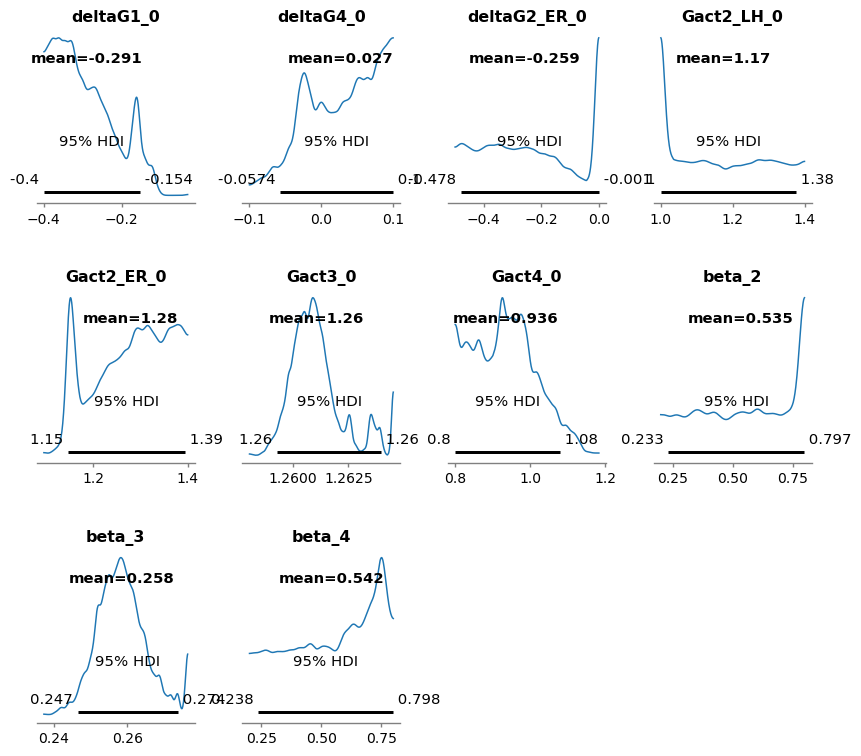

c:\Users\awast\miniconda3\envs\jdftx_env\Lib\site-packages\arviz\plots\backends\matplotlib\pairplot.py:223: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of resulting pair plots with these variables, generating only a 8x8 grid
  warnings.warn(


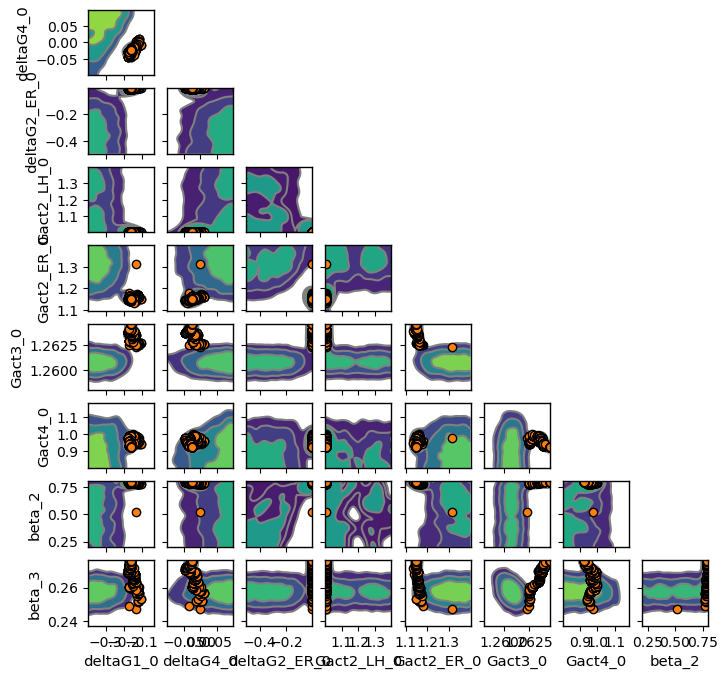

Sampling: [rate]


rate: 0.411


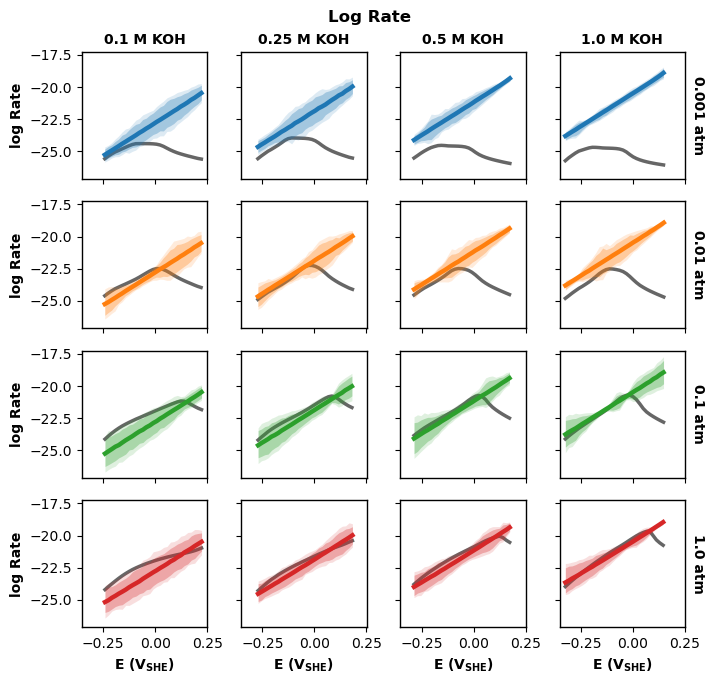

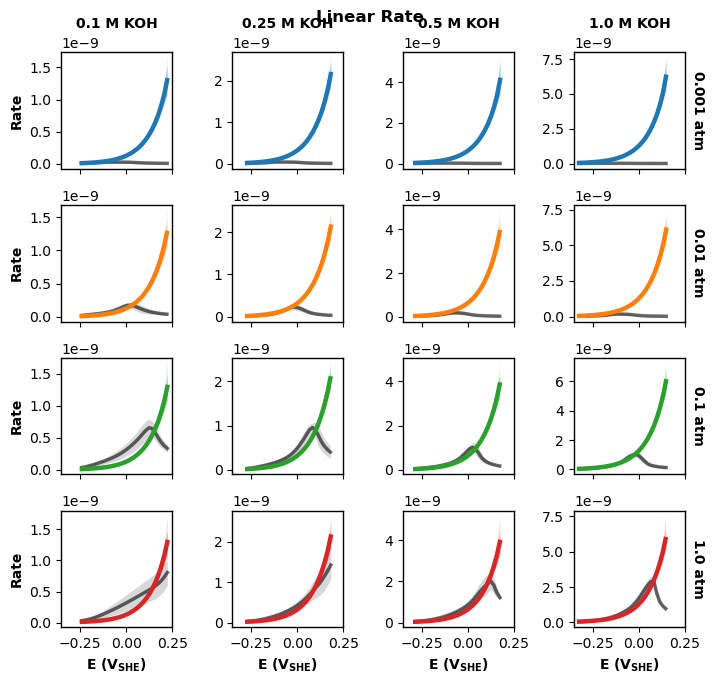

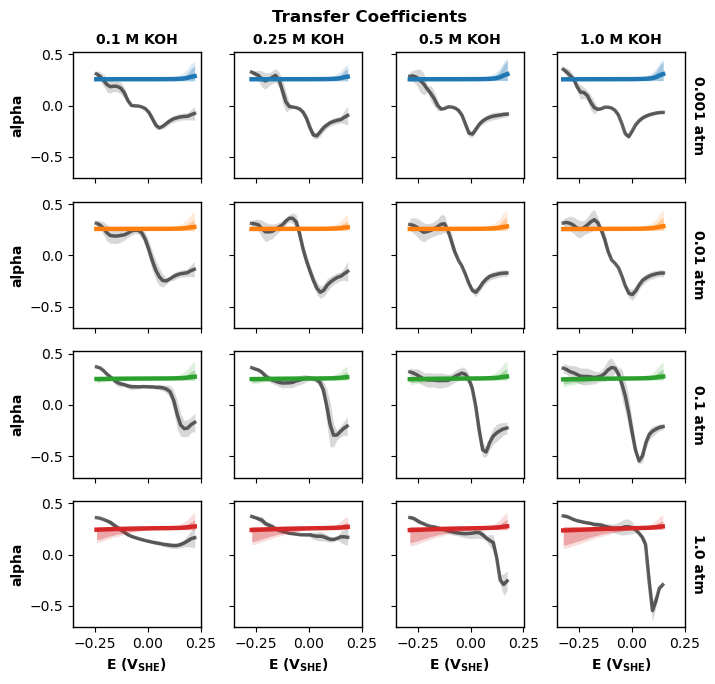

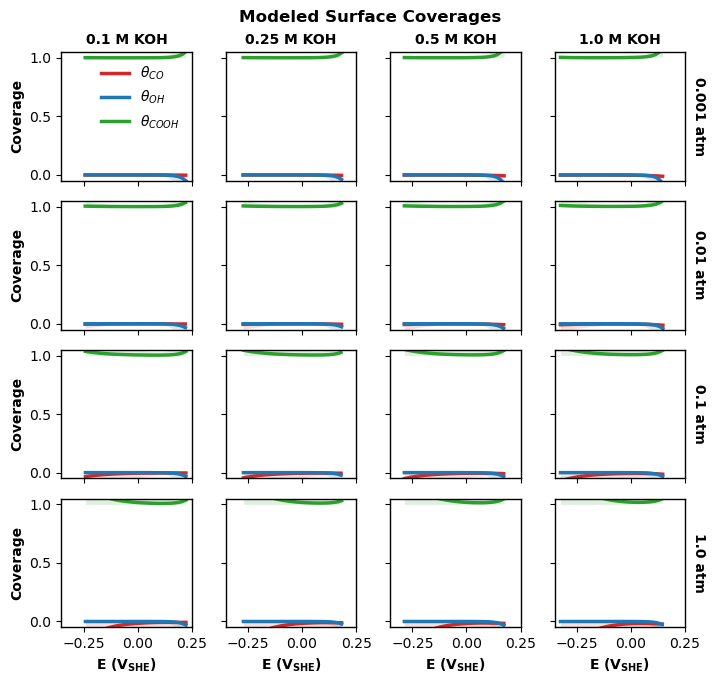

In [9]:
ppc_full = plot_posteriors(trace_full, full, format)
plot_model_fits(trace_full, ppc_full); plot_coverages(trace_full)

# Comparison

      rank     elpd_loo      p_loo   elpd_diff    weight         se        dse  warning scale
ER_2     0  -828.921582  33.707595    0.000000  0.807827  49.344329   0.000000    False   log
ER_3     1 -1389.435680  24.267067  560.514097  0.132802  65.945966  54.876504    False   log
full     2 -1618.973559  28.849608  790.051977  0.059371  79.860308  60.513673     True   log


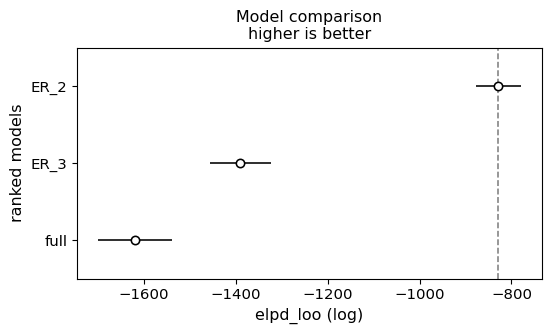

In [10]:
comparison_dict = {
    "ER_2": loo_ER_2, 
    # "LH_2": loo_LH_2, 
    "ER_3": loo_ER_3, 
    # "LH_3": loo_LH_3, 
    "full": loo_full
}
comp_df = az.compare(comparison_dict, ic="loo", method="stacking")
print(comp_df)
az.plot_compare(comp_df, insample_dev=False)
plt.show()